# Study 17 — How much evidence should we use when looking for an ability change?

## Question

Studies 15 and 16 showed that finding a genuine change in ability is a competition between the real signal and the random peaks created by searching the rest of a career.

With a permanent improvement from **58% to 64%** after frame **2,500**, the genuine change is statistically informative, but a 250-frame before-versus-after comparison still places the strongest apparent change within ±250 frames of the truth in only **38.29%** of simulated careers.

Study 16 showed that this is not a fixed failure rate. Larger real changes increasingly dominate the background noise.

But signal strength is only one side of the problem.

The detector also has to decide **how much evidence to compare on each side of every candidate change point**.

A small window reacts to a change quickly and can place it precisely, but each comparison is noisy. A large window contains more evidence and should suppress some random variation, but it may smear the transition across a much wider part of the career.

This is closely related to the trade-off from Study 09. There, the question was how much recent history to remember when estimating a player's current ability. Here, the question is whether the same responsiveness-versus-stability trade-off appears when searching for an **unknown change point**.

We will return to the original Study 15 hidden change:

**58% → 64% after frame 2,500**

and keep the simulated world otherwise unchanged:

- a 5,000-frame career;
- true frame-win probability of **58%** before the change;
- true frame-win probability of **64%** after the change;
- a permanent change after frame **2,500**;
- independent frames;
- the same simple before-versus-after detector;
- a whole-career search;
- no momentum;
- no opponent effects;
- no parameter uncertainty;
- no formal change-point algorithm.

We will vary only the number of frames compared on **each side** of a candidate point.

The window sizes will be:

- **50 frames**;
- **100 frames**;
- **250 frames**;
- **500 frames**;
- **1,000 frames**.

For each window size we will measure localisation accuracy, location error, signal-versus-background performance, and search-adjusted detection.

Crucially, each window size will receive its **own no-change calibration**. We will not reuse the +41-win threshold from Study 15, because changing the window changes both the noise in an individual contrast and the number and dependence structure of the candidate locations searched.

The central question is:

> **Do smaller windows locate changes more precisely but get fooled by noise, while larger windows suppress noise but blur the change itself?**

We are still not trying to build a smarter detector.

First we want to understand how the amount of evidence given to the same simple detector changes what it can find.

## Experimental design

We will keep the Study 15 detector unchanged and vary only the amount of evidence compared on each side of a candidate change point.

At each candidate point, the detector will compare:

- the previous \(w\) frames;
- the following \(w\) frames;

and calculate:

$$
\text{increase} = \text{wins after} - \text{wins before}
$$

We will search the whole career and retain the candidate point with the largest increase.

The window sizes tested will be:

| Frames before | Frames after | Window size per side |
|---:|---:|---:|
| 50 | 50 | 50 |
| 100 | 100 | 100 |
| 250 | 250 | 250 |
| 500 | 500 | 500 |
| 1,000 | 1,000 | 1,000 |

The simulated player will remain unchanged:

- 5,000-frame career;
- true frame-win probability of **58%** before frame 2,500;
- true frame-win probability of **64%** after frame 2,500;
- permanent change;
- independent frames.

The genuine change therefore remains:

$$
58\% \rightarrow 64\%
$$

after frame **2,500**.

For every window size we will measure:

1. how often the strongest apparent change falls within **±250 frames** of the true change;
2. median and mean absolute location error;
3. whether the strongest contrast near the genuine change beats the strongest contrast elsewhere in the career;
4. the distribution of the strongest apparent contrast under a matched **no-change** career;
5. a separately calibrated whole-career false-alarm threshold;
6. the detection rate for the genuine 58% → 64% change.

The ±250-frame localisation criterion will remain fixed across all window sizes so that the definition of success does not change with the detector.

Crucially, we will **not** reuse the +41-win threshold from Studies 15 and 16.

Changing the window size changes both:

- the noise in each individual before-versus-after comparison;
- the number and dependence structure of candidate locations searched.

Each window size therefore needs its **own no-change calibration**.

The question is not simply whether larger windows produce larger raw contrasts.

The question is:

> **How does the amount of evidence used by the detector change its ability to distinguish a real change from the strongest random fluctuations elsewhere in the career?**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fixed study parameters
career_length = 5_000
change_point = 2_500

p_before = 0.58
p_after = 0.64

window_sizes = [50, 100, 250, 500, 1_000]

localisation_tolerance = 250

n_simulations = 10_000

In [2]:
# Work out the valid search range for each window size.
#
# A candidate point needs a complete window before it and a complete window
# after it, so larger windows reduce the number of locations we can search.
#
# This is worth checking explicitly because changing the number of candidate
# locations also changes the amount of opportunity the detector has to find
# an unusually large random contrast.

candidate_summary = []

for w in window_sizes:
    first_candidate = w
    last_candidate = career_length - w
    n_candidates = last_candidate - first_candidate + 1

    candidate_summary.append(
        {
            "window": w,
            "first_candidate": first_candidate,
            "last_candidate": last_candidate,
            "n_candidates": n_candidates,
        }
    )

pd.DataFrame(candidate_summary)

,window,first_candidate,last_candidate,n_candidates
0,50,50,4950,4901
1,100,100,4900,4801
2,250,250,4750,4501
3,500,500,4500,4001
4,1000,1000,4000,3001


## Regression check against Study 15

Before comparing different window sizes, we should make sure that the new implementation still reproduces the detector we already used.

The **250-frame** condition is not a new detector.

It should be exactly the Study 15 setup:

- 250 frames before each candidate point;
- 250 frames after;
- all 4,501 valid candidate locations searched;
- strongest value of wins after minus wins before retained;
- if several locations tie for the maximum, the first location is selected.

We will therefore recreate the illustrative Study 15 career using the same random seed.

That career previously produced:

- strongest apparent improvement: **+35 wins**;
- estimated change point: **after frame 2,540**.

If we reproduce those values, we know that any later differences across window sizes are caused by changing the amount of evidence rather than accidentally changing the search procedure.

In [3]:
# Recreate the illustrative Study 15 career exactly.
#
# We use the same random seed and the same 58% -> 64% permanent change
# after frame 2,500. This gives us a known regression test for the detector
# before we start changing the window size.

rng = np.random.default_rng(15)

true_probabilities = np.full(career_length, p_before)
true_probabilities[change_point:] = p_after

career = rng.binomial(1, true_probabilities)

# Use the original Study 15 window size.
regression_window = 250

# Build cumulative wins so that every before/after window total can be
# calculated efficiently.
cumulative_wins = np.concatenate(([0], np.cumsum(career)))

# Search every location where a complete 250-frame window exists on
# both sides of the candidate point.
candidate_points = np.arange(
    regression_window,
    career_length - regression_window + 1,
)

# Count wins immediately before and immediately after every candidate point.
before_window_wins = (
    cumulative_wins[candidate_points]
    - cumulative_wins[candidate_points - regression_window]
)

after_window_wins = (
    cumulative_wins[candidate_points + regression_window]
    - cumulative_wins[candidate_points]
)

# Calculate the same deliberately simple Study 15 search statistic.
improvements = after_window_wins - before_window_wins

# np.argmax selects the first maximum if several locations tie.
# This preserves the Study 15 tie-breaking rule exactly.
best_index = np.argmax(improvements)

estimated_change_point = candidate_points[best_index]
strongest_improvement = improvements[best_index]

location_error = abs(estimated_change_point - change_point)

print(f"Candidate locations searched: {len(candidate_points):,}")
print(f"Strongest apparent improvement: +{strongest_improvement} wins")
print()
print(f"Estimated change point: after frame {estimated_change_point:,}")
print(f"True change point:      after frame {change_point:,}")
print(f"Location error:         {location_error:,} frames")

Candidate locations searched: 4,501
Strongest apparent improvement: +35 wins

Estimated change point: after frame 2,540
True change point:      after frame 2,500
Location error:         40 frames


### Regression check passed

The 250-frame implementation reproduces the original Study 15 illustrative result exactly.

It searched **4,501 candidate locations** and found:

- strongest apparent improvement: **+35 wins**;
- estimated change point: **after frame 2,540**;
- true change point: **after frame 2,500**;
- absolute location error: **40 frames**.

This is the result we expected.

The detector itself has therefore not changed.

From this point onward, we can vary the window size knowing that the **250-frame condition remains a direct regression anchor to Study 15**.

Any differences we observe between 50, 100, 250, 500 and 1,000 frames per side will therefore come from changing the amount of evidence supplied to the same search procedure.

In [4]:
# Turn the Study 15 search into one reusable function.
#
# The logic is unchanged:
#   1. search every valid candidate point;
#   2. compare wins immediately before and after that point;
#   3. calculate wins after - wins before;
#   4. keep the first location achieving the maximum.
#
# The only new feature is that the window size is now an argument.

def find_strongest_change(career, window_size):
    cumulative_wins = np.concatenate(([0], np.cumsum(career)))

    candidate_points = np.arange(
        window_size,
        len(career) - window_size + 1,
    )

    before_window_wins = (
        cumulative_wins[candidate_points]
        - cumulative_wins[candidate_points - window_size]
    )

    after_window_wins = (
        cumulative_wins[candidate_points + window_size]
        - cumulative_wins[candidate_points]
    )

    improvements = after_window_wins - before_window_wins

    # np.argmax returns the first maximum if several locations tie.
    best_index = np.argmax(improvements)

    return {
        "estimated_change_point": candidate_points[best_index],
        "strongest_improvement": improvements[best_index],
        "candidate_points": candidate_points,
        "improvements": improvements,
    }


# Check the reusable function against the known 250-frame result.
regression_result = find_strongest_change(career, 250)

print(
    "Estimated change point:",
    regression_result["estimated_change_point"],
)
print(
    "Strongest apparent improvement:",
    regression_result["strongest_improvement"],
)

Estimated change point: 2540
Strongest apparent improvement: 35


In [5]:
# Run the same illustrative career through every window size.
#
# This keeps the underlying sequence of wins and losses fixed.
# The only thing changing is how much evidence the detector uses
# on each side of a candidate change point.
#
# This gives us our first direct look at the responsiveness-versus-noise
# trade-off before we move to thousands of simulated careers.

illustrative_results = []

for w in window_sizes:
    result = find_strongest_change(career, w)

    estimated_point = result["estimated_change_point"]
    strongest_improvement = result["strongest_improvement"]
    location_error = abs(estimated_point - change_point)

    illustrative_results.append(
        {
            "window": w,
            "estimated_change_point": estimated_point,
            "location_error": location_error,
            "strongest_improvement": strongest_improvement,
        }
    )

illustrative_results_df = pd.DataFrame(illustrative_results)

illustrative_results_df

,window,estimated_change_point,location_error,strongest_improvement
0,50,507,1993,18
1,100,522,1978,23
2,250,2540,40,35
3,500,2402,98,53
4,1000,2196,304,91


## One career, five window sizes

The same simulated career produces very different estimated change points depending on how much evidence the detector uses.

| Frames per side | Estimated change | Absolute error |
|---:|---:|---:|
| 50 | 507 | 1,993 |
| 100 | 522 | 1,978 |
| 250 | 2,540 | 40 |
| 500 | 2,402 | 98 |
| 1,000 | 2,196 | 304 |

The smallest windows perform badly in this particular career.

With only 50 or 100 frames on each side, random short-term fluctuations elsewhere in the career create a stronger apparent improvement than the genuine change.

The 250-frame and 500-frame detectors both identify the correct part of the career.

The 1,000-frame detector also responds to the genuine improvement, but its estimated location is pulled much earlier. Its **304-frame error** falls just outside our fixed ±250-frame localisation criterion.

This is consistent with the trade-off we expected:

> **small windows can be highly responsive but vulnerable to noise, while very large windows may suppress noise at the cost of localisation precision.**

There is also an important warning in the final column.

The strongest raw contrast rises from **+18 wins** with a 50-frame window to **+91 wins** with a 1,000-frame window.

Those values are not directly comparable.

A larger window contains more frames, so even ordinary random variation can produce larger differences in absolute win counts.

We therefore cannot decide which window is better simply by comparing the size of its strongest contrast.

The real comparison must come from repeated careers and, ultimately, from judging each window against its **own no-change background distribution**.

This is only one illustrative career.

The next question is whether these differences persist when we repeat the experiment many times.

In [6]:
# Generate one shared set of 10,000 genuine-change careers.
#
# Every window size will be tested on exactly these same careers.
# This makes the comparison paired: if two window sizes behave differently,
# that difference comes from the detector rather than from seeing different
# random careers.
#
# We use a fresh Study 17 seed so this experiment remains reproducible
# without reusing the illustrative Study 15 career.

simulation_rng = np.random.default_rng(1701)

# Build the true probability path once:
#   frames 1–2,500     -> 58%
#   frames 2,501–5,000 -> 64%
true_probabilities = np.full(career_length, p_before)
true_probabilities[change_point:] = p_after

# Generate all genuine-change careers in one array.
#
# Shape:
#   rows    = simulated careers
#   columns = frames within each career
genuine_careers = simulation_rng.binomial(
    1,
    true_probabilities,
    size=(n_simulations, career_length),
)

# Basic checks before we use these careers in the detector.
print(f"Simulated careers: {genuine_careers.shape[0]:,}")
print(f"Frames per career: {genuine_careers.shape[1]:,}")
print()

mean_before = genuine_careers[:, :change_point].mean()
mean_after = genuine_careers[:, change_point:].mean()

print(f"Mean observed win rate before change: {mean_before:.3%}")
print(f"Mean observed win rate after change:  {mean_after:.3%}")

Simulated careers: 10,000
Frames per career: 5,000

Mean observed win rate before change: 58.013%
Mean observed win rate after change:  63.994%


In [7]:
# Search many careers with one chosen window size.
#
# We process the careers in batches rather than all at once.
# A whole-career search creates thousands of overlapping contrasts for
# every simulated career, so batching keeps memory use manageable.
#
# The detector itself is still exactly the same:
#   - compare wins before and after every valid candidate point;
#   - calculate wins after - wins before;
#   - retain the first location achieving the largest increase.

def search_many_careers(careers, window_size, batch_size=250):
    n_careers, n_frames = careers.shape

    candidate_points = np.arange(
        window_size,
        n_frames - window_size + 1,
    )

    estimated_points = np.empty(n_careers, dtype=int)
    strongest_improvements = np.empty(n_careers, dtype=int)

    for batch_start in range(0, n_careers, batch_size):
        batch_end = min(batch_start + batch_size, n_careers)

        batch = careers[batch_start:batch_end]

        # Add a leading zero so cumulative-sum differences give the number
        # of wins in any requested interval.
        cumulative_wins = np.concatenate(
            (
                np.zeros((len(batch), 1), dtype=int),
                np.cumsum(batch, axis=1),
            ),
            axis=1,
        )

        before_wins = (
            cumulative_wins[:, candidate_points]
            - cumulative_wins[:, candidate_points - window_size]
        )

        after_wins = (
            cumulative_wins[:, candidate_points + window_size]
            - cumulative_wins[:, candidate_points]
        )

        improvements = after_wins - before_wins

        # np.argmax returns the first maximum when several locations tie,
        # preserving the Study 15 tie-breaking rule.
        best_indices = np.argmax(improvements, axis=1)

        estimated_points[batch_start:batch_end] = (
            candidate_points[best_indices]
        )

        strongest_improvements[batch_start:batch_end] = improvements[
            np.arange(len(batch)),
            best_indices,
        ]

    return estimated_points, strongest_improvements

In [8]:
# Test the batched detector first with the original 250-frame window.
#
# This is another useful sanity check.
# Study 15 found 38.29% localisation across 10,000 careers using a different
# random seed, so we should expect this new sample to give a similar result,
# but not reproduce 38.29% exactly.

estimated_points_250, strongest_improvements_250 = search_many_careers(
    genuine_careers,
    250,
)

# Measure how far the selected location is from the genuine change point.
location_errors_250 = np.abs(
    estimated_points_250 - change_point
)

# A career counts as correctly localised if the strongest apparent change
# falls within our fixed ±250-frame region around the true change.
localised_250 = location_errors_250 <= localisation_tolerance

print(
    f"Correctly localised within ±{localisation_tolerance} frames: "
    f"{localised_250.mean():.2%}"
)
print(
    f"Median absolute location error: "
    f"{np.median(location_errors_250):,.0f} frames"
)
print(
    f"Mean absolute location error: "
    f"{location_errors_250.mean():,.1f} frames"
)
print(
    f"Median strongest improvement: "
    f"+{np.median(strongest_improvements_250):.0f} wins"
)
print(
    f"Mean strongest improvement: "
    f"+{strongest_improvements_250.mean():.2f} wins"
)

Correctly localised within ±250 frames: 38.92%
Median absolute location error: 582 frames
Mean absolute location error: 784.7 frames
Median strongest improvement: +32 wins
Mean strongest improvement: +32.14 wins


In [9]:
# Run the same 10,000 genuine-change careers through every window size.
#
# Because every detector sees the same underlying careers, this is a paired
# comparison. The only thing changing is the amount of evidence used on each
# side of each candidate point.
#
# For each window we record:
#   - localisation rate within ±250 frames;
#   - median and mean absolute location error;
#   - median and mean strongest apparent improvement.

window_results = []

estimated_points_by_window = {}
strongest_improvements_by_window = {}

for w in window_sizes:
    estimated_points, strongest_improvements = search_many_careers(
        genuine_careers,
        w,
    )

    location_errors = np.abs(
        estimated_points - change_point
    )

    localised = location_errors <= localisation_tolerance

    # Keep the raw arrays because later cells will need them for
    # signal-versus-background and detection analysis.
    estimated_points_by_window[w] = estimated_points
    strongest_improvements_by_window[w] = strongest_improvements

    window_results.append(
        {
            "window": w,
            "localisation_rate": localised.mean(),
            "median_location_error": np.median(location_errors),
            "mean_location_error": location_errors.mean(),
            "median_strongest_improvement": np.median(
                strongest_improvements
            ),
            "mean_strongest_improvement": strongest_improvements.mean(),
        }
    )

window_results_df = pd.DataFrame(window_results)

# Display percentage values in a more readable form.
display_results = window_results_df.copy()
display_results["localisation_rate"] = (
    display_results["localisation_rate"] * 100
)

display_results

,window,localisation_rate,median_location_error,mean_location_error,median_strongest_improvement,mean_strongest_improvement
0,50,12.33,1216.0,1211.5541,16.0,15.8757
1,100,17.98,1108.0,1115.4873,21.0,21.3854
2,250,38.92,582.0,784.7126,32.0,32.1438
3,500,59.07,172.0,432.3005,46.0,46.7945
4,1000,65.73,143.0,262.9882,75.0,76.3961


## Localisation across 10,000 careers

The one illustrative career suggested a possible trade-off between noise and localisation precision.

The repeated experiment gives us a clearer picture.

| Frames per side | Localised within ±250 | Median error | Mean error |
|---:|---:|---:|---:|
| 50 | 12.33% | 1,216 | 1,211.6 |
| 100 | 17.98% | 1,108 | 1,115.5 |
| 250 | 38.92% | 582 | 784.7 |
| 500 | 59.07% | 172 | 432.3 |
| 1,000 | 65.73% | 143 | 263.0 |

The result is stronger than the illustrative career suggested.

As the amount of evidence increases, localisation improves substantially throughout the range we tested.

The smallest windows perform particularly badly.

With only 50 frames on each side, the strongest apparent change falls within ±250 frames of the genuine change in just **12.33%** of careers.

At 100 frames this rises only to **17.98%**.

The original 250-frame detector reaches **38.92%**, closely matching the behaviour seen in Study 15.

Increasing the window further produces a large improvement:

- 500 frames per side: **59.07%** localisation;
- 1,000 frames per side: **65.73%** localisation.

Location error moves in the same direction.

The median absolute error falls from more than **1,200 frames** with the 50-frame detector to only **143 frames** with the 1,000-frame detector.

So, within the range tested, we do **not** yet see a simple point at which larger windows become so blurred that localisation starts getting worse.

The 1,000-frame detector did miss the ±250 criterion in our illustrative career, but across 10,000 careers that behaviour is not typical.

Instead, the dominant problem for the smaller windows appears to be noise:

> **With too little evidence, random local fluctuations elsewhere in the career frequently look stronger than the genuine 58% → 64% change.**

Larger windows appear to make the permanent signal sufficiently stable to overcome more of those competing random peaks.

However, this does not yet tell us the whole story.

The raw strongest contrasts increase mechanically with window size, from a mean of about **+15.88 wins** at 50 frames to **+76.40 wins** at 1,000 frames.

Those values are on different scales.

We now need to ask the more important question:

> **For each window size, how strong does the genuine-change region look compared with the strongest random contrast elsewhere in the same career?**

In [10]:
# Compare the genuine-change region with the strongest background fluctuation.
#
# For each career we divide the searchable candidate points into:
#
#   signal region:
#       within ±250 frames of the true change point;
#
#   background:
#       every other searchable candidate point.
#
# We then retain the strongest before-versus-after contrast in each region.
#
# This lets us ask a more informative question than simply whether the overall
# maximum happened near the truth:
#
#     Does the genuine-change region actually produce a stronger signal
#     than everything else in the career?


def compare_signal_and_background(
    careers,
    window_size,
    change_point,
    tolerance=250,
    batch_size=250,
):
    n_careers, n_frames = careers.shape

    candidate_points = np.arange(
        window_size,
        n_frames - window_size + 1,
    )

    # Define the genuine-change region using the same fixed ±250-frame
    # localisation criterion used throughout Studies 15–17.
    signal_mask = (
        np.abs(candidate_points - change_point) <= tolerance
    )

    background_mask = ~signal_mask

    best_signal = np.empty(n_careers, dtype=int)
    best_background = np.empty(n_careers, dtype=int)

    for batch_start in range(0, n_careers, batch_size):
        batch_end = min(batch_start + batch_size, n_careers)

        batch = careers[batch_start:batch_end]

        cumulative_wins = np.concatenate(
            (
                np.zeros((len(batch), 1), dtype=int),
                np.cumsum(batch, axis=1),
            ),
            axis=1,
        )

        before_wins = (
            cumulative_wins[:, candidate_points]
            - cumulative_wins[:, candidate_points - window_size]
        )

        after_wins = (
            cumulative_wins[:, candidate_points + window_size]
            - cumulative_wins[:, candidate_points]
        )

        improvements = after_wins - before_wins

        # Record the strongest contrast inside and outside the genuine-change
        # region separately.
        best_signal[batch_start:batch_end] = improvements[
            :, signal_mask
        ].max(axis=1)

        best_background[batch_start:batch_end] = improvements[
            :, background_mask
        ].max(axis=1)

    return best_signal, best_background


# Run the comparison for all five window sizes.
signal_background_results = []

best_signal_by_window = {}
best_background_by_window = {}

for w in window_sizes:
    best_signal, best_background = compare_signal_and_background(
        genuine_careers,
        w,
        change_point,
        localisation_tolerance,
    )

    best_signal_by_window[w] = best_signal
    best_background_by_window[w] = best_background

    signal_stronger = best_signal > best_background
    background_stronger = best_background > best_signal
    tied = best_signal == best_background

    signal_background_results.append(
        {
            "window": w,
            "signal_stronger_pct": signal_stronger.mean() * 100,
            "background_stronger_pct": background_stronger.mean() * 100,
            "tie_pct": tied.mean() * 100,
            "mean_best_signal": best_signal.mean(),
            "mean_best_background": best_background.mean(),
        }
    )

signal_background_df = pd.DataFrame(signal_background_results)

signal_background_df

,window,signal_stronger_pct,background_stronger_pct,tie_pct,mean_best_signal,mean_best_background
0,50,10.05,83.53,6.42,12.2388,15.6546
1,100,16.16,78.57,5.27,16.6687,20.8561
2,250,37.25,58.71,4.04,27.1678,29.4435
3,500,57.89,39.20,2.91,42.6947,39.6730
4,1000,64.19,32.86,2.95,72.5310,67.5618


## Signal versus background

The localisation results suggested that larger windows were making the genuine change easier to find.

Comparing the genuine-change region directly with the rest of the career confirms why.

| Frames per side | Signal stronger | Background stronger | Tie |
|---:|---:|---:|---:|
| 50 | 10.05% | 83.53% | 6.42% |
| 100 | 16.16% | 78.57% | 5.27% |
| 250 | 37.25% | 58.71% | 4.04% |
| 500 | 57.89% | 39.20% | 2.91% |
| 1,000 | 64.19% | 32.86% | 2.95% |

With the smallest windows, random fluctuations elsewhere in the career dominate overwhelmingly.

At 50 frames per side, the genuine-change region produces the stronger contrast in only **10.05%** of careers.

At 100 frames, this rises to **16.16%**.

The original 250-frame detector improves substantially, but the background still wins more often than the genuine signal:

- signal stronger: **37.25%**;
- background stronger: **58.71%**.

The crossover occurs between **250 and 500 frames per side**.

At 500 frames:

- signal stronger: **57.89%**;
- background stronger: **39.20%**.

So once the detector uses around this much evidence, the genuine 58% → 64% change begins to beat the strongest competing fluctuation elsewhere in the career more often than it loses.

The mean strongest contrasts show the same pattern:

| Frames per side | Mean best signal | Mean best background |
|---:|---:|---:|
| 50 | +12.24 | +15.65 |
| 100 | +16.67 | +20.86 |
| 250 | +27.17 | +29.44 |
| 500 | +42.69 | +39.67 |
| 1,000 | +72.53 | +67.56 |

At 50, 100 and 250 frames, the average strongest background fluctuation remains larger than the average strongest contrast near the true change.

At 500 and 1,000 frames, that relationship reverses.

This gives us a clearer interpretation of the localisation improvement:

> **Larger windows are not merely moving the estimated point around. They are increasing the chance that the genuine change produces the strongest contrast in the entire career.**

Within the range tested, the main limitation of the smaller windows is therefore not excessive blurring.

It is that they contain too little evidence to make a modest permanent change consistently stand out from the noise.

The next step is to calibrate the **no-change background separately for each window size**.

That will tell us whether a window can not only locate the genuine change, but produce evidence strong enough to count as a search-adjusted detection.

In [11]:
# Generate one shared set of 10,000 no-change careers.
#
# These careers have a constant 58% frame-win probability throughout.
# They represent the null world where there is no genuine ability change
# anywhere in the career.
#
# Every window size will be tested on exactly the same no-change careers.
# We will then use the strongest apparent whole-career contrast from each
# window to calibrate its own search-adjusted false-alarm threshold.

no_change_rng = np.random.default_rng(1702)

no_change_careers = no_change_rng.binomial(
    1,
    p_before,
    size=(n_simulations, career_length),
)

# Basic checks before using these careers for calibration.
print(f"Simulated no-change careers: {no_change_careers.shape[0]:,}")
print(f"Frames per career: {no_change_careers.shape[1]:,}")
print()
print(
    f"Mean observed win rate: "
    f"{no_change_careers.mean():.3%}"
)

Simulated no-change careers: 10,000
Frames per career: 5,000

Mean observed win rate: 57.996%


In [12]:
# Search all 10,000 no-change careers with every window size.
#
# There is no real change in these careers, so every apparent improvement
# found by the detector is produced entirely by random variation.
#
# The strongest contrast in each career therefore tells us how large a
# completely spurious "change" can look after searching the whole career.
#
# We keep these arrays because the next step will use them to calibrate a
# separate false-alarm threshold for each window size.

no_change_results = []

no_change_strongest_by_window = {}

for w in window_sizes:
    _, strongest_improvements = search_many_careers(
        no_change_careers,
        w,
    )

    no_change_strongest_by_window[w] = strongest_improvements

    no_change_results.append(
        {
            "window": w,
            "median_strongest_improvement": np.median(
                strongest_improvements
            ),
            "mean_strongest_improvement": strongest_improvements.mean(),
            "p95_strongest_improvement": np.percentile(
                strongest_improvements,
                95,
            ),
            "maximum_strongest_improvement": strongest_improvements.max(),
        }
    )

no_change_results_df = pd.DataFrame(no_change_results)

no_change_results_df

,window,median_strongest_improvement,mean_strongest_improvement,p95_strongest_improvement,maximum_strongest_improvement
0,50,16.0,16.0227,19.0,26
1,100,21.0,21.3507,27.0,37
2,250,30.0,30.3337,40.0,59
3,500,37.0,38.0385,52.0,76
4,1000,43.0,44.1135,67.0,113


## The no-change background hurdle

The no-change simulations show how large an apparent improvement can look even when ability never changes.

| Frames per side | Median strongest contrast | Mean strongest contrast | 95th percentile | Maximum |
|---:|---:|---:|---:|---:|
| 50 | +16 | +16.02 | +19 | +26 |
| 100 | +21 | +21.35 | +27 | +37 |
| 250 | +30 | +30.33 | +40 | +59 |
| 500 | +37 | +38.04 | +52 | +76 |
| 1,000 | +43 | +44.11 | +67 | +113 |

The background hurdle itself grows with window size.

This is expected.

A 1,000-frame comparison contains far more observations than a 50-frame comparison, so differences measured in raw win counts naturally operate on a larger scale.

That means a +40-win contrast cannot mean the same thing for every detector.

For a 250-frame window, +40 wins is already close to the extreme tail of the no-change distribution.

For a 1,000-frame window, +40 wins is entirely ordinary.

This confirms the methodological point we fixed at the start of the study:

> **Each window size must be judged against its own no-change background distribution.**

The next step is therefore to convert these distributions into separate search-adjusted thresholds.

For each window size, we will find the smallest integer contrast whose observed whole-career false-alarm rate falls below **5%**.

In [13]:
# Calibrate a separate whole-career false-alarm threshold for each window.
#
# For each no-change distribution, we test integer thresholds and find the
# smallest contrast for which fewer than 5% of simulated careers produce
# a strongest apparent improvement at or above that value.
#
# This is the same search-adjusted idea used in Studies 15 and 16, but now
# calibrated independently for every window size.

threshold_results = []

threshold_by_window = {}

for w in window_sizes:
    strongest_improvements = no_change_strongest_by_window[w]

    # Search upward through all possible integer thresholds.
    for threshold in range(
        strongest_improvements.min(),
        strongest_improvements.max() + 2,
    ):
        false_alarm_rate = (
            strongest_improvements >= threshold
        ).mean()

        if false_alarm_rate < 0.05:
            threshold_by_window[w] = threshold

            threshold_results.append(
                {
                    "window": w,
                    "threshold": threshold,
                    "false_alarm_rate_pct": false_alarm_rate * 100,
                }
            )
            break

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,window,threshold,false_alarm_rate_pct
0,50,20,4.52
1,100,28,3.01
2,250,41,3.78
3,500,53,4.86
4,1000,68,4.87


## The no-change background hurdle

The no-change simulations show how large an apparent improvement can look even when ability never changes.

| Frames per side | Median strongest contrast | Mean strongest contrast | 95th percentile | Maximum |
|---:|---:|---:|---:|---:|
| 50 | +16 | +16.02 | +19 | +26 |
| 100 | +21 | +21.35 | +27 | +37 |
| 250 | +30 | +30.33 | +40 | +59 |
| 500 | +37 | +38.04 | +52 | +76 |
| 1,000 | +43 | +44.11 | +67 | +113 |

The background hurdle itself grows with window size.

This is expected.

A 1,000-frame comparison contains far more observations than a 50-frame comparison, so differences measured in raw win counts naturally operate on a larger scale.

That means a +40-win contrast cannot mean the same thing for every detector.

For a 250-frame window, +40 wins is already close to the extreme tail of the no-change distribution.

For a 1,000-frame window, +40 wins is entirely ordinary.

This confirms the methodological point we fixed at the start of the study:

> **Each window size must be judged against its own no-change background distribution.**

The next step is therefore to convert these distributions into separate search-adjusted thresholds.

For each window size, we will find the smallest integer contrast whose observed whole-career false-alarm rate falls below **5%**.

In [14]:
# Calibrate a separate whole-career false-alarm threshold for each window.
#
# For each no-change distribution, we test integer thresholds and find the
# smallest contrast for which fewer than 5% of simulated careers produce
# a strongest apparent improvement at or above that value.
#
# This is the same search-adjusted idea used in Studies 15 and 16, but now
# calibrated independently for every window size.

threshold_results = []

threshold_by_window = {}

for w in window_sizes:
    strongest_improvements = no_change_strongest_by_window[w]

    # Search upward through all possible integer thresholds.
    for threshold in range(
        strongest_improvements.min(),
        strongest_improvements.max() + 2,
    ):
        false_alarm_rate = (
            strongest_improvements >= threshold
        ).mean()

        if false_alarm_rate < 0.05:
            threshold_by_window[w] = threshold

            threshold_results.append(
                {
                    "window": w,
                    "threshold": threshold,
                    "false_alarm_rate_pct": false_alarm_rate * 100,
                }
            )
            break

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,window,threshold,false_alarm_rate_pct
0,50,20,4.52
1,100,28,3.01
2,250,41,3.78
3,500,53,4.86
4,1000,68,4.87


## Search-adjusted thresholds

Each window size requires a different threshold before an apparent change becomes unusual relative to a whole-career no-change search.

| Frames per side | Detection threshold | Observed false-alarm rate |
|---:|---:|---:|
| 50 | +20 wins | 4.52% |
| 100 | +28 wins | 3.01% |
| 250 | +41 wins | 3.78% |
| 500 | +53 wins | 4.86% |
| 1,000 | +68 wins | 4.87% |

The threshold rises substantially as the comparison window grows.

This does not mean that larger windows are intrinsically more demanding.

It reflects the fact that raw win-count differences operate on different scales.

A +20-win contrast is already unusual after searching an entire no-change career with 50-frame windows.

With 1,000 frames on each side, the equivalent search-adjusted hurdle is +68 wins.

The 250-frame condition provides another useful check on the implementation.

Its calibrated threshold is:

**+41 wins**

This is the same integer threshold found in Studies 15 and 16.

The observed false-alarm rate differs slightly because Study 17 uses a fresh set of 10,000 no-change careers, but the underlying calibration reproduces the previous result.

We can now compare the genuine 58% → 64% careers fairly.

For each window size, an apparent change will count as a detection only if its strongest whole-career contrast reaches that window's own calibrated threshold.

The remaining question is:

> **Does using more evidence make the genuine change more likely to clear its corresponding search-adjusted hurdle?**

In [15]:
# Apply each window's own search-adjusted threshold to the genuine-change careers.
#
# For every window size we measure:
#
#   detection rate:
#       strongest whole-career contrast reaches the calibrated threshold;
#
#   detected + localised:
#       the threshold is reached and the selected change point lies within
#       ±250 frames of the genuine change;
#
#   localised among detections:
#       among careers that trigger a detection, how often does that detection
#       point to the correct region?
#
# This separates two different questions:
#
#   1. Is the evidence strong enough to count as unusual?
#   2. If it is unusual, does it actually point to the real change?

detection_results = []

for w in window_sizes:
    threshold = threshold_by_window[w]

    strongest_improvements = strongest_improvements_by_window[w]
    estimated_points = estimated_points_by_window[w]

    detected = strongest_improvements >= threshold

    location_errors = np.abs(
        estimated_points - change_point
    )

    localised = location_errors <= localisation_tolerance

    detected_and_localised = detected & localised

    detection_rate = detected.mean()
    detected_localised_rate = detected_and_localised.mean()

    if detected.sum() > 0:
        localised_among_detections = (
            detected_and_localised.sum() / detected.sum()
        )
    else:
        localised_among_detections = np.nan

    detection_results.append(
        {
            "window": w,
            "threshold": threshold,
            "detection_rate_pct": detection_rate * 100,
            "detected_and_localised_pct": detected_localised_rate * 100,
            "localised_among_detections_pct": (
                localised_among_detections * 100
            ),
        }
    )

detection_results_df = pd.DataFrame(detection_results)

detection_results_df

,window,threshold,detection_rate_pct,detected_and_localised_pct,localised_among_detections_pct
0,50,20,4.12,0.53,12.864078
1,100,28,3.26,0.88,26.993865
2,250,41,7.80,5.11,65.512821
3,500,53,25.86,20.78,80.355762
4,1000,68,67.74,49.77,73.472099


## Search-adjusted detection

We can now judge each detector against the no-change hurdle appropriate to its own window size.

| Frames per side | Threshold | Detection rate | Detected + localised | Localised among detections |
|---:|---:|---:|---:|---:|
| 50 | +20 | 4.12% | 0.53% | 12.86% |
| 100 | +28 | 3.26% | 0.88% | 26.99% |
| 250 | +41 | 7.80% | 5.11% | 65.51% |
| 500 | +53 | 25.86% | 20.78% | 80.36% |
| 1,000 | +68 | 67.74% | 49.77% | 73.47% |

The smallest windows are extremely poor at detecting this permanent six-percentage-point improvement.

With 50 or 100 frames on each side, the overall detection rate is only around **3–4%**.

These windows contain too little evidence for the genuine change to consistently separate itself from the extreme random fluctuations produced by a whole-career search.

The original 250-frame detector does better, but still detects the change in only **7.80%** of careers.

Increasing the window to 500 frames changes the picture substantially:

- **25.86%** of careers produce a search-adjusted detection;
- **20.78%** are both detected and correctly localised.

The 1,000-frame window produces the strongest overall performance:

- **67.74%** of careers produce a search-adjusted detection;
- **49.77%** are both detected and localised within ±250 frames.

There is an apparent complication in the final column.

Localisation among detections rises to **80.36%** at 500 frames and then falls to **73.47%** at 1,000 frames.

However, this does **not** by itself show that the larger window places detected changes less precisely.

The two percentages are calculated over very different sets of careers:

- the 500-frame detector finds **2,586** detections;
- the 1,000-frame detector finds **6,774**.

The 1,000-frame detector is therefore bringing thousands of additional, harder careers into the calculation.

We will examine that apparent localisation penalty directly before interpreting it as evidence of blurring.

The result we can already state confidently is:

> **Using more evidence makes this modest permanent change dramatically easier to distinguish from the strongest random fluctuations generated by a whole-career search.**

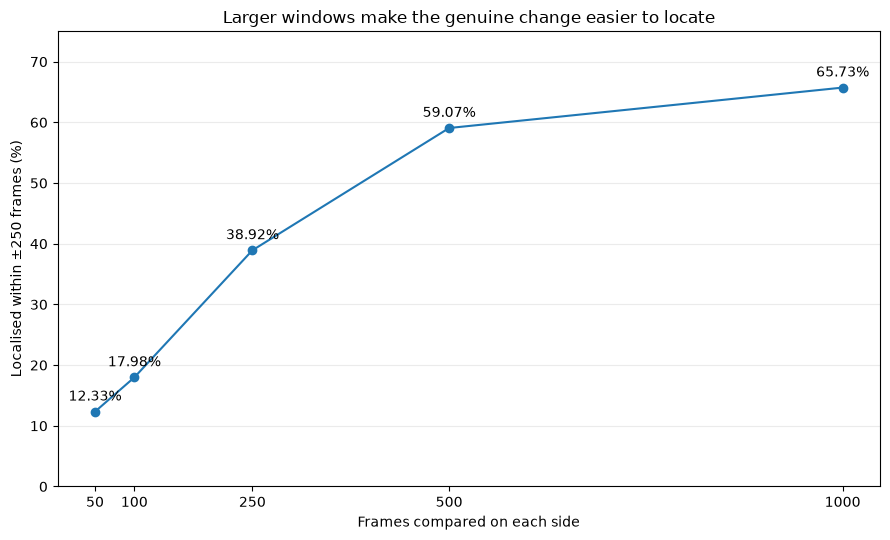

In [16]:
# Plot localisation accuracy against the amount of evidence used on each side
# of a candidate change point.
#
# This is the simplest summary of the main result so far:
# larger windows make the genuine 58% -> 64% change much more likely to
# produce the strongest apparent improvement in the correct part of the career.

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(
    window_results_df["window"],
    window_results_df["localisation_rate"] * 100,
    marker="o",
)

# Label each point so the exact simulation result remains visible without
# needing to estimate values from the axis.
for _, row in window_results_df.iterrows():
    ax.annotate(
        f'{row["localisation_rate"] * 100:.2f}%',
        (
            row["window"],
            row["localisation_rate"] * 100,
        ),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
    )

ax.set_title("Larger windows make the genuine change easier to locate")
ax.set_xlabel("Frames compared on each side")
ax.set_ylabel("Localised within ±250 frames (%)")

ax.set_xticks(window_sizes)
ax.set_ylim(0, 75)

ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### Localisation improves with more evidence

The repeated simulation shows a strong relationship between window size and our ability to locate the genuine change.

Localisation rises from only **12.33%** with 50 frames on each side to **65.73%** with 1,000 frames.

The largest gains occur through the middle of the range:

- 50 frames: **12.33%**;
- 100 frames: **17.98%**;
- 250 frames: **38.92%**;
- 500 frames: **59.07%**;
- 1,000 frames: **65.73%**.

So the improvement is not unlimited.

Moving from 250 to 500 frames adds about **20 percentage points** of localisation accuracy.

Moving from 500 to 1,000 adds only about **7 percentage points**.

Within the range tested, larger windows therefore continue to help, but the benefit begins to flatten.

The key result is:

> **For this modest permanent 58% → 64% change, using too little evidence leaves the detector vulnerable to stronger-looking random fluctuations elsewhere in the career.**

But localisation alone does not tell us whether the evidence would be strong enough to justify claiming that a change occurred.

We now need to compare the **search-adjusted detection performance** of the five window sizes.

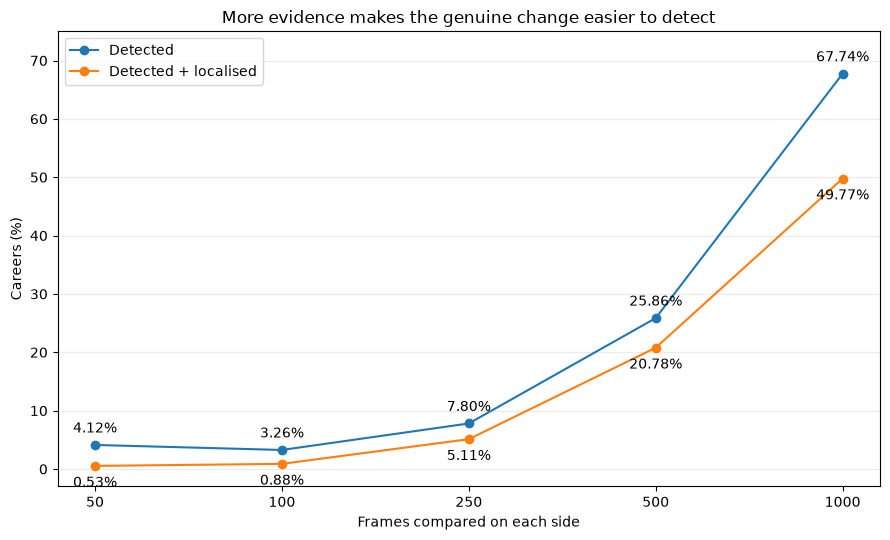

In [17]:
# Plot search-adjusted detection performance for each window size.
#
# The five window sizes are discrete experimental conditions, so we give
# them equal spacing on the x-axis. This avoids visually compressing the
# 50- and 100-frame results simply because their numerical values are close.
#
# We show:
#
#   detection rate:
#       the strongest whole-career contrast clears that window's own
#       no-change threshold;
#
#   detected + localised:
#       the threshold is cleared and the selected point is within ±250
#       frames of the genuine change.

fig, ax = plt.subplots(figsize=(9, 5.5))

x_positions = np.arange(len(window_sizes))

ax.plot(
    x_positions,
    detection_results_df["detection_rate_pct"],
    marker="o",
    label="Detected",
)

ax.plot(
    x_positions,
    detection_results_df["detected_and_localised_pct"],
    marker="o",
    label="Detected + localised",
)

# Label the exact simulation results.
for i, row in detection_results_df.iterrows():
    ax.annotate(
        f'{row["detection_rate_pct"]:.2f}%',
        (x_positions[i], row["detection_rate_pct"]),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
    )

    ax.annotate(
        f'{row["detected_and_localised_pct"]:.2f}%',
        (x_positions[i], row["detected_and_localised_pct"]),
        xytext=(0, -15),
        textcoords="offset points",
        ha="center",
    )

ax.set_title("More evidence makes the genuine change easier to detect")
ax.set_xlabel("Frames compared on each side")
ax.set_ylabel("Careers (%)")

ax.set_xticks(x_positions)
ax.set_xticklabels(window_sizes)

ax.set_ylim(-3, 75)

ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

### Detection depends strongly on window size

Once each detector is judged against its own no-change threshold, the effect of window size becomes even clearer.

The smallest windows provide almost no useful search-adjusted detection power.

At 50 frames per side, only **4.12%** of genuine-change careers cross the threshold, compared with a **4.52%** false-alarm rate in the matched no-change simulations.

At 100 frames, the corresponding figures are **3.26%** and **3.01%**.

So at these window sizes, a genuine permanent 58% → 64% improvement is barely more likely to trigger the detector than ordinary random variation.

The picture begins to change at 250 frames:

- detection rate: **7.80%**;
- detected and correctly localised: **5.11%**.

At 500 frames the improvement is much stronger:

- detection rate: **25.86%**;
- detected and correctly localised: **20.78%**.

And with 1,000 frames on each side:

- **67.74%** of careers produce a search-adjusted detection;
- **49.77%** are both detected and localised within ±250 frames.

This shows why the raw increase in win counts was not enough.

The larger windows also face larger no-change thresholds, yet the genuine permanent signal increasingly clears those thresholds anyway.

> **For a modest permanent change, accumulating more evidence can transform a signal that is almost indistinguishable from noise into one that is detectable in a majority of careers.**

The gap between overall detection and detected-plus-localised performance is larger at 1,000 frames than at 500.

But that gap needs careful interpretation.

The two window sizes detect very different numbers of careers, so a simple comparison of localisation among detections does not tell us whether the larger window genuinely places the same changes less precisely.

We therefore need to compare localisation on the **same detected careers** before deciding whether the larger window creates a blurring penalty.

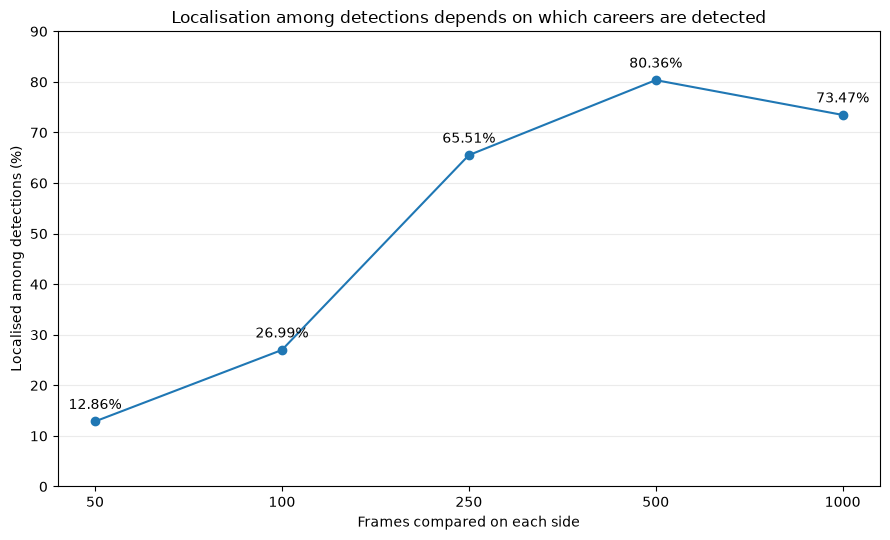

In [18]:
# Compare localisation among detections for each window size.
#
# This percentage is useful descriptively, but it needs care:
# different window sizes detect different sets of careers.
#
# In particular, the 1,000-frame detector finds many more of the difficult
# careers that the 500-frame detector never detects at all. A lower percentage
# among detections therefore does not, by itself, prove that the larger window
# places the same detected changes less precisely.

fig, ax = plt.subplots(figsize=(9, 5.5))

x_positions = np.arange(len(window_sizes))

ax.plot(
    x_positions,
    detection_results_df["localised_among_detections_pct"],
    marker="o",
)

for i, row in detection_results_df.iterrows():
    ax.annotate(
        f'{row["localised_among_detections_pct"]:.2f}%',
        (
            x_positions[i],
            row["localised_among_detections_pct"],
        ),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
    )

ax.set_title("Localisation among detections depends on which careers are detected")
ax.set_xlabel("Frames compared on each side")
ax.set_ylabel("Localised among detections (%)")

ax.set_xticks(x_positions)
ax.set_xticklabels(window_sizes)

ax.set_ylim(0, 90)

ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Does the largest window actually blur the change?

At first glance, the search-adjusted results appeared to show a localisation trade-off.

Among detected careers:

- 500-frame window: **80.36%** localised within ±250 frames;
- 1,000-frame window: **73.47%** localised within ±250 frames.

It would be tempting to conclude that the larger window detects changes more easily but places them less precisely.

However, those percentages are calculated over very different groups of careers.

The 500-frame detector produces **2,586 detections**, while the 1,000-frame detector produces **6,774**.

The larger window is therefore detecting thousands of additional careers that never enter the 500-frame calculation.

To make a fair precision comparison, we examined only the **2,374 careers detected by both windows**.

| Measure | 500 frames | 1,000 frames |
|---|---:|---:|
| Median absolute error | 83 | 85 |
| Mean absolute error | 196.6 | 148.6 |
| Within ±250 frames | 82.73% | 84.29% |

On these same careers, the two windows have almost identical median error.

The 1,000-frame window actually has the lower mean error and a slightly higher probability of falling within ±250 frames.

Looking career by career:

- 500-frame estimate closer: **43.26%**;
- 1,000-frame estimate closer: **45.03%**;
- identical error: **11.71%**.

So the apparent downturn in localisation among all detections does **not** provide convincing evidence that the 1,000-frame window genuinely blurs the location.

Instead, it is largely a consequence of **selection**:

> **the 1,000-frame detector finds many more difficult careers, changing the population over which localisation among detections is calculated.**

Within the window sizes tested here, increasing the amount of evidence continues to improve detection dramatically without producing a clear localisation penalty on comparable cases.

That is a stronger result than we expected at the start of the study.

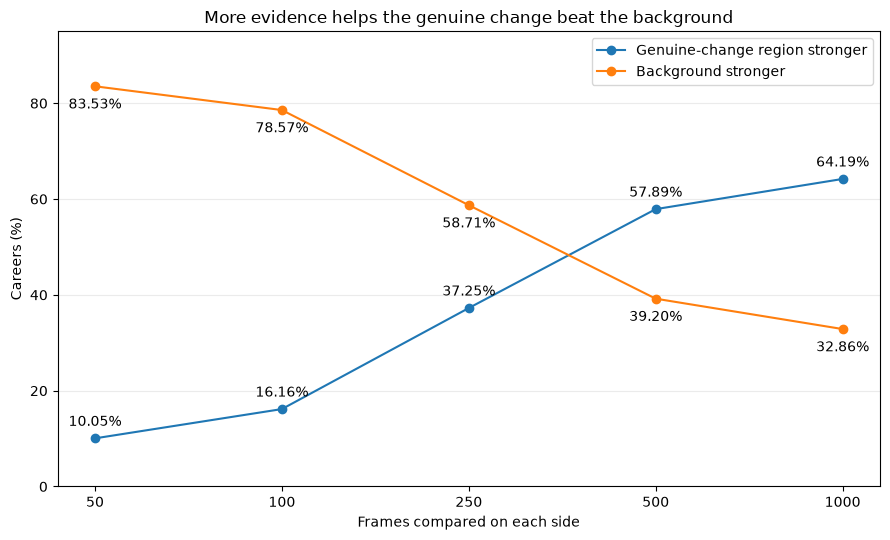

In [19]:
# Plot how often the genuine-change region beats the strongest competing
# fluctuation elsewhere in the career.
#
# This gets directly at the mechanism behind the localisation results.
#
# Small windows are noisy enough that the background usually produces the
# strongest apparent improvement.
#
# As the window grows, the genuine permanent 58% -> 64% change increasingly
# wins that competition.

fig, ax = plt.subplots(figsize=(9, 5.5))

x_positions = np.arange(len(window_sizes))

ax.plot(
    x_positions,
    signal_background_df["signal_stronger_pct"],
    marker="o",
    label="Genuine-change region stronger",
)

ax.plot(
    x_positions,
    signal_background_df["background_stronger_pct"],
    marker="o",
    label="Background stronger",
)

# Label the exact simulation results.
for i, row in signal_background_df.iterrows():
    ax.annotate(
        f'{row["signal_stronger_pct"]:.2f}%',
        (
            x_positions[i],
            row["signal_stronger_pct"],
        ),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
    )

    ax.annotate(
        f'{row["background_stronger_pct"]:.2f}%',
        (
            x_positions[i],
            row["background_stronger_pct"],
        ),
        xytext=(0, -16),
        textcoords="offset points",
        ha="center",
    )

ax.set_title("More evidence helps the genuine change beat the background")
ax.set_xlabel("Frames compared on each side")
ax.set_ylabel("Careers (%)")

ax.set_xticks(x_positions)
ax.set_xticklabels(window_sizes)

ax.set_ylim(0, 95)

ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

### The genuine signal eventually overtakes the background

The signal-versus-background comparison shows why localisation improves as the window grows.

With small windows, the strongest random fluctuation elsewhere in the career usually looks more impressive than the genuine change.

At 50 frames per side:

- genuine-change region stronger: **10.05%**;
- background stronger: **83.53%**.

At 100 frames:

- genuine-change region stronger: **16.16%**;
- background stronger: **78.57%**.

The original 250-frame detector is better, but the background still wins more often:

- genuine-change region stronger: **37.25%**;
- background stronger: **58.71%**.

The crossover occurs between **250 and 500 frames per side**.

At 500 frames:

- genuine-change region stronger: **57.89%**;
- background stronger: **39.20%**.

At 1,000 frames:

- genuine-change region stronger: **64.19%**;
- background stronger: **32.86%**.

So the improvement in localisation has a simple explanation:

> **As the detector uses more evidence, the genuine permanent change becomes more likely to produce a stronger contrast than the best random fluctuation elsewhere in the career.**

This is the central mechanism behind Study 17.

The detector itself has not become smarter.

It is still performing the same simple before-versus-after comparison.

What changes is the amount of evidence available to each comparison.

With too little evidence, random fluctuations dominate.

With more evidence, the real 58% → 64% shift increasingly wins the competition against the background.

## Conclusion

Study 17 asked how much evidence a simple change detector should use when the location of a genuine ability change is unknown.

We returned to the same permanent change studied previously:

$$
58\% \rightarrow 64\%
$$

after frame **2,500** of a 5,000-frame career.

The detector itself never changed.

At every possible candidate point it simply compared the number of wins before and after that point and searched the whole career for the largest increase.

The only quantity varied was the number of frames used on each side:

- 50;
- 100;
- 250;
- 500;
- 1,000.

The initial expectation was a trade-off.

Small windows might locate a change precisely but be easily fooled by noise.

Large windows might suppress noise but eventually blur the location of the change.

The first half of that expectation was strongly supported.

Small windows performed badly because random fluctuations elsewhere in the career regularly looked stronger than the genuine change.

Localisation within ±250 frames rose from:

- **12.33%** at 50 frames;
- **17.98%** at 100 frames;
- **38.92%** at 250 frames;
- **59.07%** at 500 frames;
- **65.73%** at 1,000 frames.

The signal-versus-background comparison showed why.

At 250 frames, the strongest background fluctuation still beat the genuine-change region in **58.71%** of careers.

At 500 frames, that relationship reversed:

- genuine-change region stronger: **57.89%**;
- background stronger: **39.20%**.

More evidence made the permanent signal increasingly capable of beating the strongest random fluctuation produced elsewhere in the career.

The search-adjusted detection results were even more striking.

After separately calibrating the no-change threshold for every window size, detection of the genuine 58% → 64% change rose from only a few percent with the smallest windows to:

- **25.86%** at 500 frames;
- **67.74%** at 1,000 frames.

Almost half of all careers using the 1,000-frame detector — **49.77%** — were both detected and localised within ±250 frames.

The expected blurring penalty was much less clear.

At first, localisation among detected careers appeared to fall from **80.36%** at 500 frames to **73.47%** at 1,000 frames.

But those percentages were based on very different sets of careers because the 1,000-frame detector found far more changes.

When we compared only the **2,374 careers detected by both windows**, the apparent penalty disappeared.

The two windows had almost identical median errors:

- 500 frames: **83 frames**;
- 1,000 frames: **85 frames**.

The 1,000-frame detector actually had the lower mean error and slightly higher localisation within ±250 frames.

So within the range tested, we do **not** find convincing evidence that using more evidence creates a meaningful localisation penalty.

Instead, the dominant problem is the opposite:

> **using too little evidence leaves a modest permanent ability change buried beneath the random peaks created by searching the rest of the career.**

This reconnects directly to Study 09, but with an important difference.

Study 09 showed that shorter windows respond more quickly when estimating a player's current ability.

Study 17 shows that when the task is instead to find an **unknown permanent change**, responsiveness alone is not enough.

The detector needs sufficient evidence for the genuine signal to distinguish itself from the strongest background noise.

The central result is therefore:

> **For this permanent 58% → 64% change, more evidence made the change substantially easier both to find and to detect, and the expected loss of localisation precision did not clearly appear within the 50–1,000-frame range tested.**

This does not mean that ever-larger windows must always be better.

We tested only five window sizes, one career length, one centrally located abrupt permanent change and one deliberately simple detector.

We should not extrapolate beyond that experiment.

But within this world, the main lesson is clear:

> **When the change is modest but permanent, too little evidence is a bigger problem than too much — at least across the window sizes tested here.**